<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/image_processing/image_processing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Selected first 1243 images from the dataset extracted from : https://www.kaggle.com/datasets/jessicali9530/celeba-dataset/data

Stored 1243 images in folder "image_folder"

In [8]:
import pandas as pd
import numpy as np
import os
from PIL import Image

folder_path = "/content/drive/MyDrive/AI-python/lecture36/image_folder"

images = []
filenames = []

for file in os.listdir(folder_path):
    if file.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
        path = os.path.join(folder_path, file)

        try:
            img = Image.open(path)
            images.append(img)
            filenames.append(file)
        except:
            print("Corrupted file:", file)

print("Total images loaded:", len(images))

Total images loaded: 1243


Describe the data

In [2]:
widths = []
heights = []
modes = []

for img in images:
    w, h = img.size
    widths.append(w)
    heights.append(h)
    modes.append(img.mode)

print("Min width:", min(widths))
print("Max width:", max(widths))
print("Min height:", min(heights))
print("Max height:", max(heights))
print("Color types:", set(modes))

Min width: 178
Max width: 178
Min height: 218
Max height: 218
Color types: {'RGB'}


Detect bad images and remove

In [3]:
bad_images = []

for file in os.listdir(folder_path):
    path = os.path.join(folder_path, file)

    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(file)

print("Bad images:", bad_images)

for file in bad_images:
    os.remove(os.path.join(folder_path, file))

Bad images: []


In [4]:
IMG_SIZE = 128

clean_images = []

for img in images:
    img = img.convert("RGB")       # ensure RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0    # normalize
    clean_images.append(img)

clean_images = np.array(clean_images)

print(clean_images.shape)

(1243, 128, 128, 3)


Data visualization

In [7]:

data_summary = pd.DataFrame({
    "filename": filenames,
    "width": widths,
    "height": heights,
    "mode": modes
})

print(data_summary.head())

     filename  width  height mode
0  000952.jpg    178     218  RGB
1  000174.jpg    178     218  RGB
2  000127.jpg    178     218  RGB
3  000440.jpg    178     218  RGB
4  000253.jpg    178     218  RGB


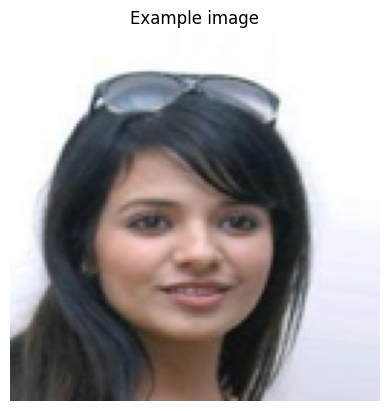

In [6]:
import matplotlib.pyplot as plt

plt.imshow(clean_images[0])
plt.title("Example image")
plt.axis("off")
plt.show()